In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def jalankan_clustering_dan_visualisasi(nama_file):
    try:
        # 1. Membaca dataset (CSV atau Excel)
        if nama_file.endswith('creditcard.csv'):
            df = pd.read_csv(nama_file)
        elif nama_file.endswith('creditcard.csv') or nama_file.endswith('creditcard.csv'):
            df = pd.read_excel(nama_file)
        else:
            print("Format file tidak didukung. Gunakan file .csv atau .xlsx")
            return

        # 2. Seleksi kolom numerik & Handling Missing Values
        X = df.select_dtypes(include=['float64', 'int64']).dropna()
        if X.empty:
            print("Error: Tidak ditemukan kolom numerik di dataset Anda.")
            return

        # 3. Standarisasi Data
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # 4. K-Means Clustering (Sesuai gambar, K=2)
        JUMLAH_CLUSTER = 2
        kmeans = KMeans(n_clusters=JUMLAH_CLUSTER, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_scaled)
        
        # Simpan hasil cluster ke dataframe asli
        df['Label_Klaster'] = labels

        # 5. Reduksi Dimensi dengan PCA menjadi 2 Komponen (PC1 & PC2)
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_scaled)

        # ==========================================
        # SCRIPT UNTUK MEMBUAT GRAFIK (PROSES VISUALISASI)
        # ==========================================
        plt.figure(figsize=(10, 7.5))

        # Membuat scatter plot mendetail sesuai gambar Anda
        # Menggunakan cmap='Set1' untuk skema warna merah-abu abu, edgecolor='k' untuk outline hitam
        scatter = plt.scatter(
            X_pca[:, 0], 
            X_pca[:, 1], 
            c=labels, 
            cmap='Set1', 
            alpha=0.6,          # Efek agak transparan
            edgecolors='k',     # Garis tepi lingkaran warna hitam
            linewidths=0.8,     # Ketebalan garis tepi
            s=40                # Ukuran titik data
        )

        # Menambahkan Judul dan Label Sumbu
        plt.title("Visualisasi Hasil K-Means Clustering Setelah Reduksi PCA (K=2)", fontsize=14, fontweight='bold', pad=15)
        plt.xlabel("Principal Component 1 (PC1)", fontsize=12)
        plt.ylabel("Principal Component 2 (PC2)", fontsize=12)

        # Menambahkan Garis Kisi-Kisi (Grid) Putus-Putus
        plt.grid(True, linestyle='--', alpha=0.7)

        # Menambahkan Colorbar di Sebelah Kanan
        colorbar = plt.colorbar(scatter, ticks=np.linspace(0, 1, 6))
        colorbar.set_label('Label Klaster', fontsize=11, rotation=270, labelpad=15)

        # Menyimpan gambar hasil plot ke laptop Anda
        nama_gambar = 'hasil_clustering_pca.png'
        plt.tight_layout()
        plt.savefig(nama_gambar, dpi=300)
        print(f"✓ Grafik visualisasi berhasil disimpan dengan nama: '{nama_gambar}'")
        
        # Menampilkan grafik di layar
        plt.show()

    except FileNotFoundError:
        print(f"Error: File '{nama_file}' tidak ditemukan.")
    except Exception as e:
        print(f"Terjadi kesalahan: {e}")

✓ Grafik visualisasi berhasil disimpan dengan nama: 'hasil_clustering_pca.png'


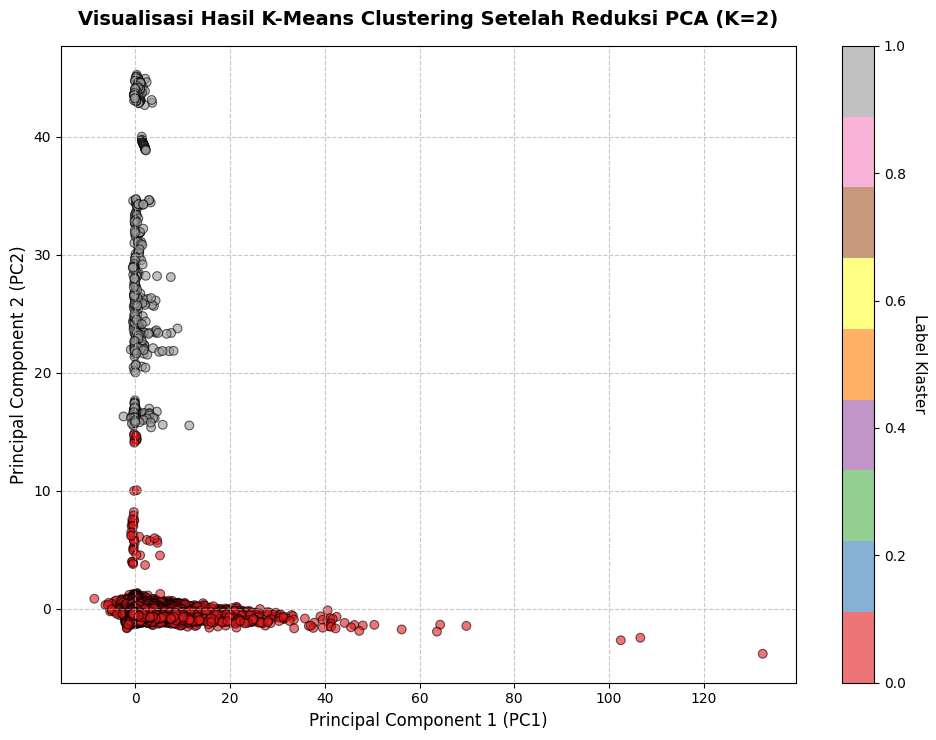

In [2]:
# --- UBAH NAMA FILE DI SINI ---
# Masukkan nama file dataset Anda yang ingin diplot
NAMA_FILE_DATASET = 'creditcard.csv' 

# Jalankan fungsi utama
jalankan_clustering_dan_visualisasi(NAMA_FILE_DATASET)